In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 97.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f5d59cf6819c8297b765b00c4baab8aac38c2a5c4fa50f618da61b9e8a6bd948
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


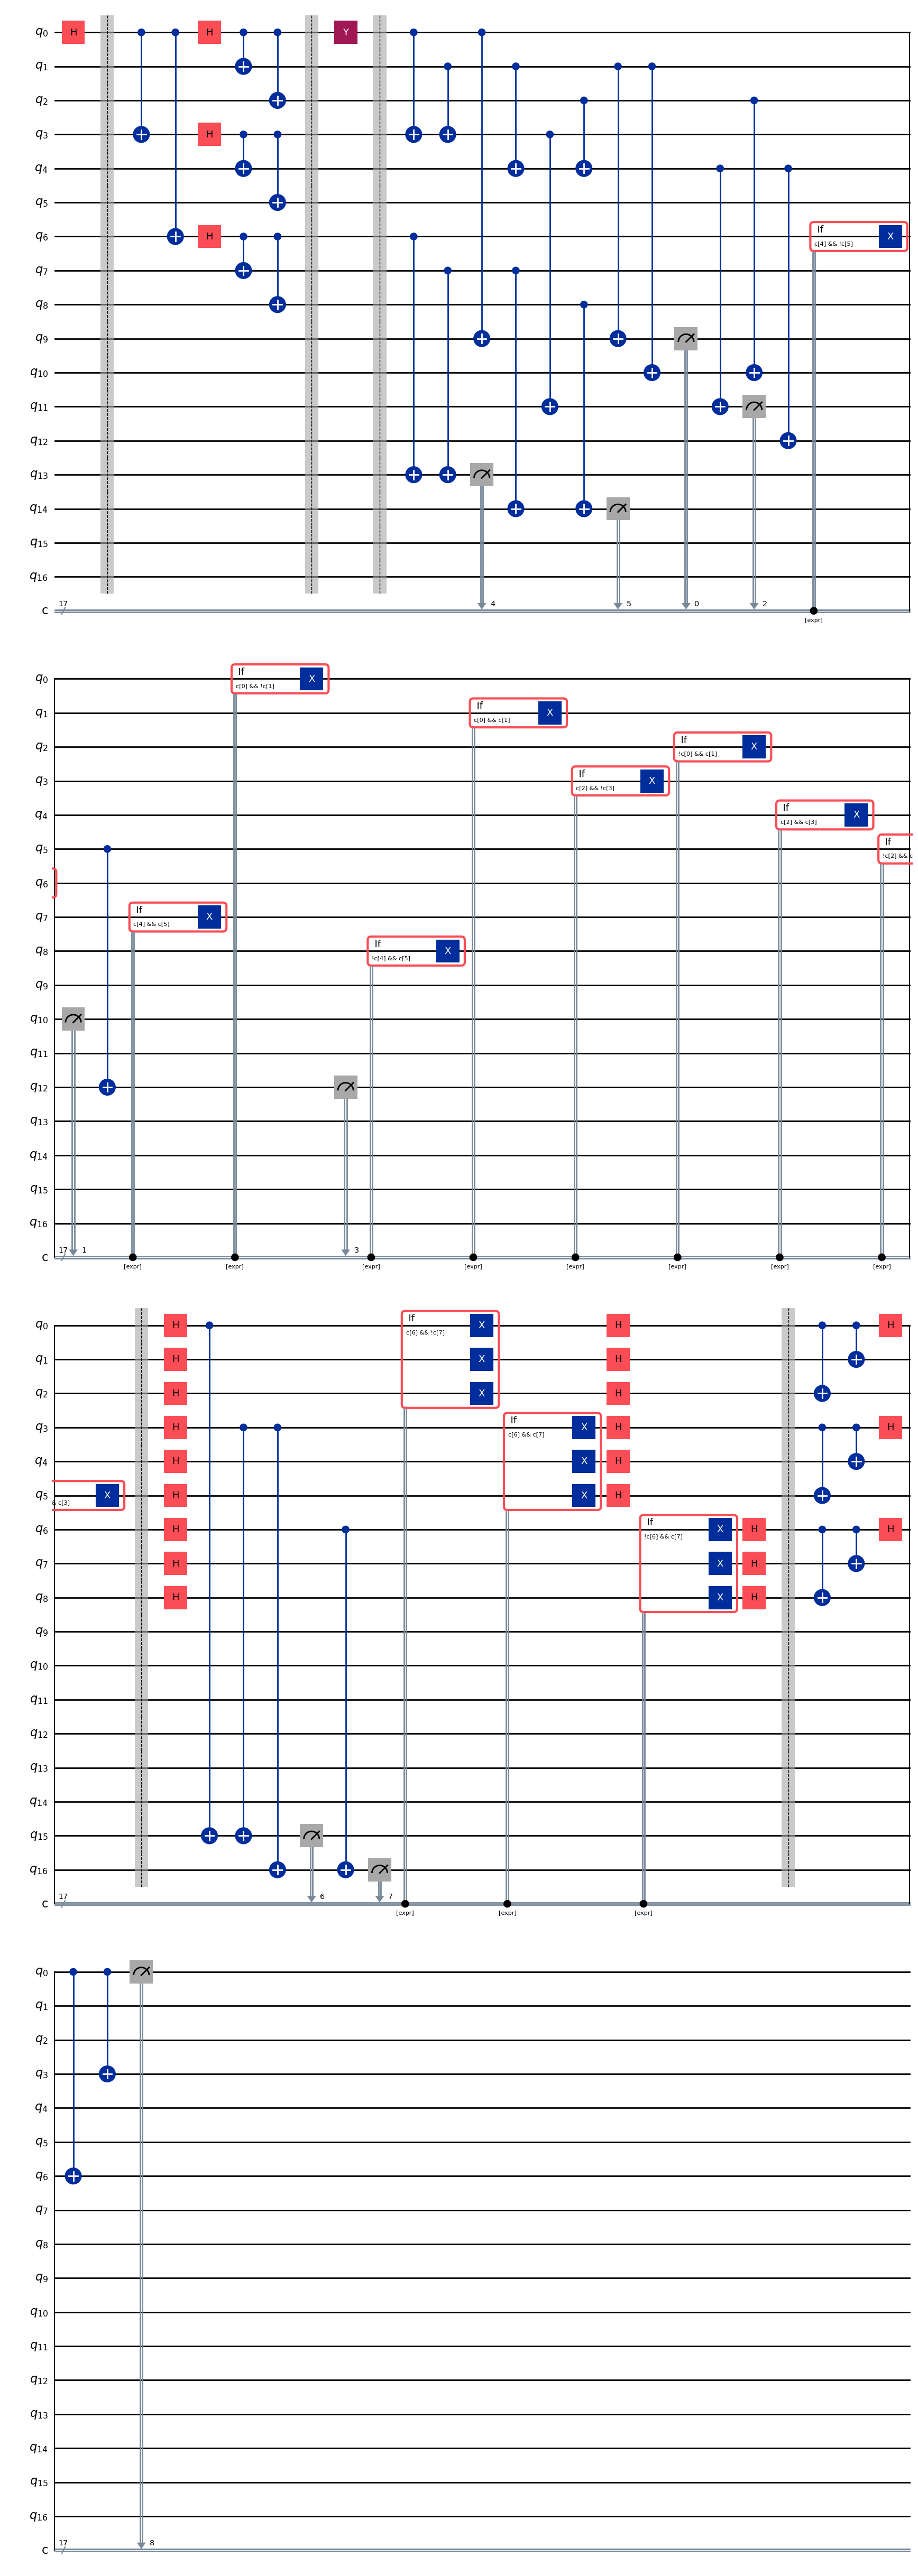

In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.

shor = QuantumCircuit(17, 17)

shor.h(0)
shor.barrier()

shor.cx(0, 3)
shor.cx(0, 6)
shor.h([0, 3, 6])

shor.cx(0, 1)
shor.cx(0, 2)
shor.cx(3, 4)
shor.cx(3, 5)
shor.cx(6, 7)
shor.cx(6, 8)
shor.barrier()

shor.y(0)
shor.barrier()


shor.cx(0,3)
shor.cx(1,3)
shor.cx(1,4)
shor.cx(2,4)

def correct_bit_flip(qc, b0, b1, b2, a0, a1, c0, c1):
    qc.cx(b0, a0)
    qc.cx(b1, a0)
    qc.cx(b1, a1)
    qc.cx(b2, a1)
    qc.measure([a0, a1], [c0, c1])

    with qc.if_test(expr.logic_and(qc.clbits[c0], expr.logic_not(qc.clbits[c1]))):
        qc.x(b0)
    with qc.if_test(expr.logic_and(qc.clbits[c0], qc.clbits[c1])):
        qc.x(b1)
    with qc.if_test(expr.logic_and(expr.logic_not(qc.clbits[c0]), qc.clbits[c1])):
        qc.x(b2)

correct_bit_flip(shor, 0, 1, 2, 9, 10, 0, 1)
correct_bit_flip(shor, 3, 4, 5, 11, 12, 2, 3)
correct_bit_flip(shor, 6, 7, 8, 13, 14, 4, 5)
shor.barrier()

shor.h([0,1,2,3,4,5,6,7,8])
shor.cx(0, 15)
shor.cx(3, 15)
shor.cx(3, 16)
shor.cx(6, 16)
shor.measure([15, 16], [6, 7])

with shor.if_test(expr.logic_and(shor.clbits[6], expr.logic_not(shor.clbits[7]))):
    shor.x([0,1,2])
with shor.if_test(expr.logic_and(shor.clbits[6], shor.clbits[7])):
    shor.x([3,4,5])
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[6]), shor.clbits[7])):
    shor.x([6,7,8])


shor.h([0,1,2,3,4,5,6,7,8])
shor.barrier()

shor.cx(6, 8)
shor.cx(6, 7)
shor.cx(3, 5)
shor.cx(3, 4)
shor.cx(0, 2)
shor.cx(0, 1)

shor.h([0, 3, 6])
shor.cx(0, 6)
shor.cx(0, 3)

shor.measure(0, 8)

shor.draw("mpl")


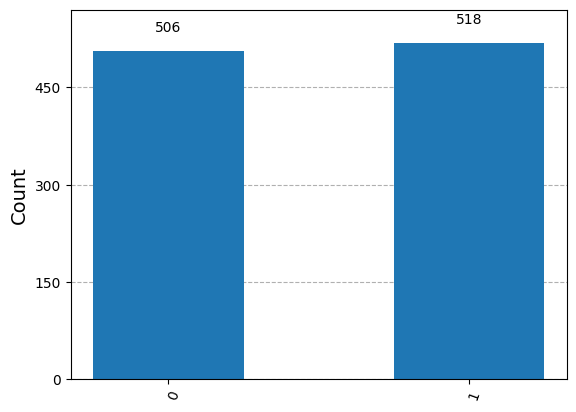

In [6]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=17, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[8])
plot_histogram(mcounts)